In [2]:
#Load and inspect
import pandas as pd


df = pd.read_csv('/content/data.csv', encoding='latin1')

print(df.shape)
df.info()
df.isnull().sum()

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [3]:
#Clean the data
# Drop rows with missing CustomerID (can't segment without it)
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with 'C') and non-positive quantities
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
#Calculate RFM using SQL (SQLite, in-memory)
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, index=False, if_exists='replace')

query = """
WITH customer_orders AS (
    SELECT
        CustomerID,
        MAX(InvoiceDate) AS last_purchase,
        COUNT(DISTINCT InvoiceNo) AS frequency,
        SUM(TotalPrice) AS monetary
    FROM transactions
    GROUP BY CustomerID
)
SELECT
    CustomerID,
    last_purchase,
    frequency,
    monetary,
    NTILE(4) OVER (ORDER BY frequency DESC) AS freq_score,
    NTILE(4) OVER (ORDER BY monetary DESC) AS monetary_score
FROM customer_orders
"""
rfm = pd.read_sql(query, conn)
rfm.head()

,CustomerID,last_purchase,frequency,monetary,freq_score,monetary_score
0,12748.0,2011-12-09 12:20:00,209,33719.73,1,1
1,14911.0,2011-12-08 15:54:00,201,143825.06,1,1
2,17841.0,2011-12-08 12:07:00,124,40991.57,1,1
3,13089.0,2011-12-07 09:02:00,97,58825.83,1,1
4,14606.0,2011-12-08 19:28:00,93,12156.65,1,1


In [5]:
#Calculate Recency and combine scores
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm['last_purchase'] = pd.to_datetime(rfm['last_purchase'])
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

rfm['recency_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['RFM_Score'] = (rfm['recency_score'].astype(str)
                     + rfm['freq_score'].astype(str)
                     + rfm['monetary_score'].astype(str))
rfm.head()

,CustomerID,last_purchase,frequency,monetary,freq_score,monetary_score,recency,recency_score,RFM_Score
0,12748.0,2011-12-09 12:20:00,209,33719.73,1,1,1,4,411
1,14911.0,2011-12-08 15:54:00,201,143825.06,1,1,1,4,411
2,17841.0,2011-12-08 12:07:00,124,40991.57,1,1,2,4,411
3,13089.0,2011-12-07 09:02:00,97,58825.83,1,1,3,4,411
4,14606.0,2011-12-08 19:28:00,93,12156.65,1,1,1,4,411


In [6]:
#Segment customers
def segment(row):
    if row['recency_score'] in [4,3] and row['freq_score'] in [1,2]:
        return 'Champions'
    elif row['recency_score'] in [1,2]:
        return 'At Risk'
    elif row['freq_score'] in [1,2]:
        return 'Loyal Customers'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
At Risk,2150
Champions,1518
Needs Attention,670


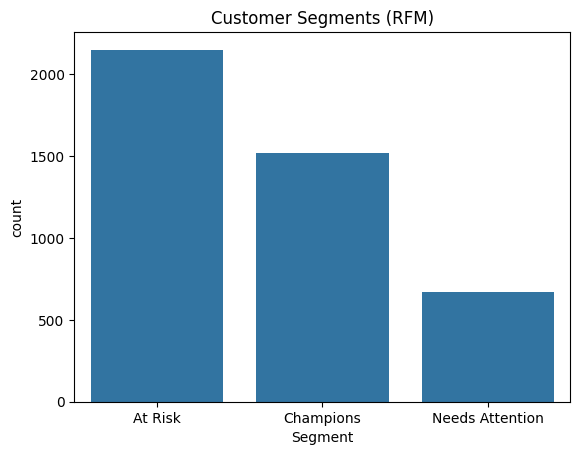

In [7]:
#Visualize the segments
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.title('Customer Segments (RFM)')
plt.show()

In [8]:
# What share of total revenue comes from each segment?
revenue_share = rfm.groupby('Segment')['monetary'].sum().sort_values(ascending=False)
print(revenue_share / revenue_share.sum() * 100)

Segment
Champions          76.696153
At Risk            20.289494
Needs Attention     3.014354
Name: monetary, dtype: float64


In [9]:
#Export data
from google.colab import files
rfm.to_csv('rfm_segments.csv', index=False)
files.download('rfm_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>